## Data Analytics with Python

Final Project: Data Analytics with Python

Include the following 12 criteria:

1. Data Preprocessing (or Data Cleaning)
2. Impute missing values using MICE
3. Data Normalization
4. One-Hot Encoding on categorical column
5. Feature Importance
6. Outlier Detection
7. Correlation Matrix and Heatmaps
8. Model Training
9. Evaluation Metrics
10. Comparisons
11. ROC curve
12. Visualization charts of at least 5 types

Import the required libraries

In [1]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

For this project, we will follow the standard Data Analytics workflow

Data Collection: Import (or load) data from various sources: CSV, Excel, JSON, SQL, MongoDB Databases, etc.

In [2]:
# Read the dataset
df = pd.read_csv('heart_disease.csv')
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,No,26.63,No,No,No,0,3,No,Female,65-69,Black,Yes,Yes,Very good,6,No,No,No
4995,No,NaN,Yes,No,No,0,0,No,Male,30-34,White,No,Yes,Very good,7,No,No,No
4996,No,31.89,Yes,Yes,No,0,2,No,Female,55-59,White,No,No,Very good,6,No,No,NaN
4997,No,27.26,Yes,No,No,0,0,Yes,Male,60-64,Other,Yes,Yes,Good,7,No,No,No


Data Cleaning (or Data Preparation, Data Preprocessing): Handling missing values, duplicates, outliers, redundant features, inconsistent data formats.

In [3]:
# Get information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      4999 non-null   object 
 1   BMI               4962 non-null   float64
 2   Smoking           4999 non-null   object 
 3   AlcoholDrinking   4999 non-null   object 
 4   Stroke            4996 non-null   object 
 5   PhysicalHealth    4999 non-null   int64  
 6   MentalHealth      4999 non-null   int64  
 7   DiffWalking       4999 non-null   object 
 8   Sex               4997 non-null   object 
 9   AgeCategory       4999 non-null   object 
 10  Race              4964 non-null   object 
 11  Diabetic          4992 non-null   object 
 12  PhysicalActivity  4998 non-null   object 
 13  GenHealth         4999 non-null   object 
 14  SleepTime         4999 non-null   int64  
 15  Asthma            4961 non-null   object 
 16  KidneyDisease     4985 non-null   object 


In [4]:
# Get Descriptive Statistics
df.describe(include='all').fillna('No info')

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
count,4999,4962.0,4999,4999,4996,4999.0,4999.0,4999,4997,4999,4964,4992,4998,4999,4999.0,4961,4985,4964
unique,2,No info,2,2,2,No info,No info,2,2,13,6,4,2,5,No info,2,2,2
top,No,No info,No,No,No,No info,No info,No,Female,65-69,White,No,Yes,Very good,No info,No,No,No
freq,4471,No info,2844,4753,4722,No info,No info,4066,2882,616,3544,4027,3608,1599,No info,4262,4754,4349
mean,No info,29.23653,No info,No info,No info,4.04921,4.284857,No info,No info,No info,No info,No info,No info,No info,7.068414,No info,No info,No info
std,No info,6.611566,No info,No info,No info,8.51139,8.442191,No info,No info,No info,No info,No info,No info,No info,1.573757,No info,No info,No info
min,No info,12.48,No info,No info,No info,0.0,0.0,No info,No info,No info,No info,No info,No info,No info,1.0,No info,No info,No info
25%,No info,24.56,No info,No info,No info,0.0,0.0,No info,No info,No info,No info,No info,No info,No info,6.0,No info,No info,No info
50%,No info,28.19,No info,No info,No info,0.0,0.0,No info,No info,No info,No info,No info,No info,No info,7.0,No info,No info,No info
75%,No info,32.89,No info,No info,No info,3.0,4.0,No info,No info,No info,No info,No info,No info,No info,8.0,No info,No info,No info


In [5]:
# Count the missing values
df.isna().sum()

HeartDisease         0
BMI                 37
Smoking              0
AlcoholDrinking      0
Stroke               3
PhysicalHealth       0
MentalHealth         0
DiffWalking          0
Sex                  2
AgeCategory          0
Race                35
Diabetic             7
PhysicalActivity     1
GenHealth            0
SleepTime            0
Asthma              38
KidneyDisease       14
SkinCancer          35
dtype: int64

Determine numerical and categorical columns since:
- We will use MICE algorithm to impute numerical columns
- For categorical columns, we simply impute them with the mode

In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numerical columns:", num_cols.tolist())
print("Categorical columns:", cat_cols.tolist())

Numerical columns: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
Categorical columns: ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']


- Impute the numerical columns using MICE
- Impute the Categorical columns with mode (most_frequent)

In [7]:
# Apply MICE algorithm
mice = IterativeImputer(max_iter=10, random_state=0)
df[num_cols] = mice.fit_transform(df[num_cols])
# Simple Imputer
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.600000,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.340000,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.580000,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.210000,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.710000,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,No,26.630000,No,No,No,0.0,3.0,No,Female,65-69,Black,Yes,Yes,Very good,6.0,No,No,No
4995,No,28.852958,Yes,No,No,0.0,0.0,No,Male,30-34,White,No,Yes,Very good,7.0,No,No,No
4996,No,31.890000,Yes,Yes,No,0.0,2.0,No,Female,55-59,White,No,No,Very good,6.0,No,No,No
4997,No,27.260000,Yes,No,No,0.0,0.0,Yes,Male,60-64,Other,Yes,Yes,Good,7.0,No,No,No


In [8]:
# Check
df.isna().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

Get unique values in each column, might be useful to determine the category

In [9]:
# Get the unique categories in each column
print("Unique values in each column")
for i in df.columns:
    print(f"{i}: {df[i].unique()}")

Unique values in each column
HeartDisease: ['No' 'Yes']
BMI: [16.6        20.34       26.58       ... 29.23956776 26.69
 37.03      ]
Smoking: ['Yes' 'No']
AlcoholDrinking: ['No' 'Yes']
Stroke: ['No' 'Yes']
PhysicalHealth: [ 3.  0. 20. 28.  6. 15.  5. 30.  7.  1.  2. 21.  4. 10. 14. 18.  8. 25.
 16. 29. 27. 17. 24. 12. 23. 26. 22. 19.  9. 13.]
MentalHealth: [30.  0.  2.  5. 15.  8.  4.  3. 10. 14. 20.  1.  7. 24.  9. 28. 16. 12.
  6. 25. 17. 18. 21. 29. 22. 13. 23. 27.]
DiffWalking: ['No' 'Yes']
Sex: ['Female' 'Male']
AgeCategory: ['55-59' '80 or older' '65-69' '75-79' '40-44' '70-74' '60-64' '50-54'
 '45-49' '18-24' '35-39' '30-34' '25-29']
Race: ['White' 'Black' 'Asian' 'American Indian/Alaskan Native' 'Other'
 'Hispanic']
Diabetic: ['Yes' 'No' 'No, borderline diabetes' 'Yes (during pregnancy)']
PhysicalActivity: ['Yes' 'No']
GenHealth: ['Very good' 'Fair' 'Good' 'Poor' 'Excellent']
SleepTime: [ 5.  7.  8.  6. 12.  4.  9. 10. 15.  3.  2.  1. 16. 18. 14. 20. 11.]
Asthma: ['Yes' 'No']


Drop duplicate columns

In [10]:
df.drop_duplicates()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.600000,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.340000,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.580000,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.210000,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.710000,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,No,26.630000,No,No,No,0.0,3.0,No,Female,65-69,Black,Yes,Yes,Very good,6.0,No,No,No
4995,No,28.852958,Yes,No,No,0.0,0.0,No,Male,30-34,White,No,Yes,Very good,7.0,No,No,No
4996,No,31.890000,Yes,Yes,No,0.0,2.0,No,Female,55-59,White,No,No,Very good,6.0,No,No,No
4997,No,27.260000,Yes,No,No,0.0,0.0,Yes,Male,60-64,Other,Yes,Yes,Good,7.0,No,No,No


3.  Data Transformation: Normalize values, encode categorical to numerical, derived variables, segmentation numerical variable to groups.

Get binary columns, and apply Label Encoding (Mapping)

In [11]:
# We will apply Label Encoding for Binary values (only Yes and No)
binary_cols = [i for i in cat_cols if len(df[i].unique()) == 2]

print("Binary Categorical Columns:", binary_cols)
# Label Encoding
label_encoder = LabelEncoder()
for i in binary_cols:
    df[i] = label_encoder.fit_transform(df[i])

df

Binary Categorical Columns: ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.600000,1,0,0,3.0,30.0,0,0,55-59,White,Yes,1,Very good,5.0,1,0,1
1,0,20.340000,0,0,1,0.0,0.0,0,0,80 or older,White,No,1,Very good,7.0,0,0,0
2,0,26.580000,1,0,0,20.0,30.0,0,1,65-69,White,Yes,1,Fair,8.0,1,0,0
3,0,24.210000,0,0,0,0.0,0.0,0,0,75-79,White,No,0,Good,6.0,0,0,1
4,0,23.710000,0,0,0,28.0,0.0,1,0,40-44,White,No,1,Very good,8.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,0,26.630000,0,0,0,0.0,3.0,0,0,65-69,Black,Yes,1,Very good,6.0,0,0,0
4995,0,28.852958,1,0,0,0.0,0.0,0,1,30-34,White,No,1,Very good,7.0,0,0,0
4996,0,31.890000,1,1,0,0.0,2.0,0,0,55-59,White,No,0,Very good,6.0,0,0,0
4997,0,27.260000,1,0,0,0.0,0.0,1,1,60-64,Other,Yes,1,Good,7.0,0,0,0


Get non-binary categorical columns for One-Hot Encoding and Ordinal Encoding

In [12]:
# One-Hot Encoding
non_binary_cols = [j for j in cat_cols if j not in binary_cols]

print("Non-Binary Categorical Columns:", non_binary_cols)

Non-Binary Categorical Columns: ['AgeCategory', 'Race', 'Diabetic', 'GenHealth']


From understanding dataset, we determine the ordinal columns and the non-ordinal columns
- Categorical columns with possible ranking (ordinality): Age_category and GenHealth
    - Because the GenHealth has columns like Fair, Good, and Excellent -> Magnitude-based values
    - And the column Age_category has columns like 18-24, 25-29, 30-34, 35-39 -> Possible age progression category

- Categorical columns without ranking: Race and Diabetic
    - Race determines a person's origin 
    - Diabetic: A person might have diabetic during or after their pregnancy

Ordinal Encoding for each specific column

In [13]:
ordinal_cols = pd.Index(non_binary_cols).drop(['Race', 'Diabetic'])
non_ordinal_cols = pd.Index(non_binary_cols).drop(['AgeCategory', 'GenHealth'])
 
print("Ordinal Columns:")
for k in ordinal_cols:
    print(df[k].unique())

print("Non-Ordinal Columns:")
for n in non_ordinal_cols:
    print(df[n].unique())

Ordinal Columns:
['55-59' '80 or older' '65-69' '75-79' '40-44' '70-74' '60-64' '50-54'
 '45-49' '18-24' '35-39' '30-34' '25-29']
['Very good' 'Fair' 'Good' 'Poor' 'Excellent']
Non-Ordinal Columns:
['White' 'Black' 'Asian' 'American Indian/Alaskan Native' 'Other'
 'Hispanic']
['Yes' 'No' 'No, borderline diabetes' 'Yes (during pregnancy)']


In [14]:
# Define ordered categories
age_categories = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', 
                  '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older']

gen_health_categories = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
# Apply Ordinal Encoding
ordinal_encoder = OrdinalEncoder(categories=[age_categories, gen_health_categories], 
                                 handle_unknown='use_encoded_value', unknown_value=-1)

df[['AgeCategory', 'GenHealth']] = ordinal_encoder.fit_transform(df[['AgeCategory', 'GenHealth']])

df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.600000,1,0,0,3.0,30.0,0,0,7.0,White,Yes,1,3.0,5.0,1,0,1
1,0,20.340000,0,0,1,0.0,0.0,0,0,12.0,White,No,1,3.0,7.0,0,0,0
2,0,26.580000,1,0,0,20.0,30.0,0,1,9.0,White,Yes,1,1.0,8.0,1,0,0
3,0,24.210000,0,0,0,0.0,0.0,0,0,11.0,White,No,0,2.0,6.0,0,0,1
4,0,23.710000,0,0,0,28.0,0.0,1,0,4.0,White,No,1,3.0,8.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,0,26.630000,0,0,0,0.0,3.0,0,0,9.0,Black,Yes,1,3.0,6.0,0,0,0
4995,0,28.852958,1,0,0,0.0,0.0,0,1,2.0,White,No,1,3.0,7.0,0,0,0
4996,0,31.890000,1,1,0,0.0,2.0,0,0,7.0,White,No,0,3.0,6.0,0,0,0
4997,0,27.260000,1,0,0,0.0,0.0,1,1,8.0,Other,Yes,1,2.0,7.0,0,0,0


One-Hot Encoding for each specific column

In [15]:
# One-Hot Encoding
one_hot_encoder = OneHotEncoder(sparse_output=False)
# Return a matrix
one_hot_data = one_hot_encoder.fit_transform(df[['Race', 'Diabetic']])
# Get feature names
one_hot_cols = one_hot_encoder.get_feature_names_out(['Race', 'Diabetic'])

# Read as dataframe
encoded_df = pd.DataFrame(one_hot_data, columns=one_hot_cols)

# Concatenation
df = pd.concat([df.drop(['Race', 'Diabetic'], axis=1), encoded_df], axis=1)
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0,16.600000,1,0,0,3.0,30.0,0,0,7.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0,20.340000,0,0,1,0.0,0.0,0,0,12.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0,26.580000,1,0,0,20.0,30.0,0,1,9.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0,24.210000,0,0,0,0.0,0.0,0,0,11.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0,23.710000,0,0,0,28.0,0.0,1,0,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,0,26.630000,0,0,0,0.0,3.0,0,0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4995,0,28.852958,1,0,0,0.0,0.0,0,1,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4996,0,31.890000,1,1,0,0.0,2.0,0,0,7.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4997,0,27.260000,1,0,0,0.0,0.0,1,1,8.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Correlation Matrix

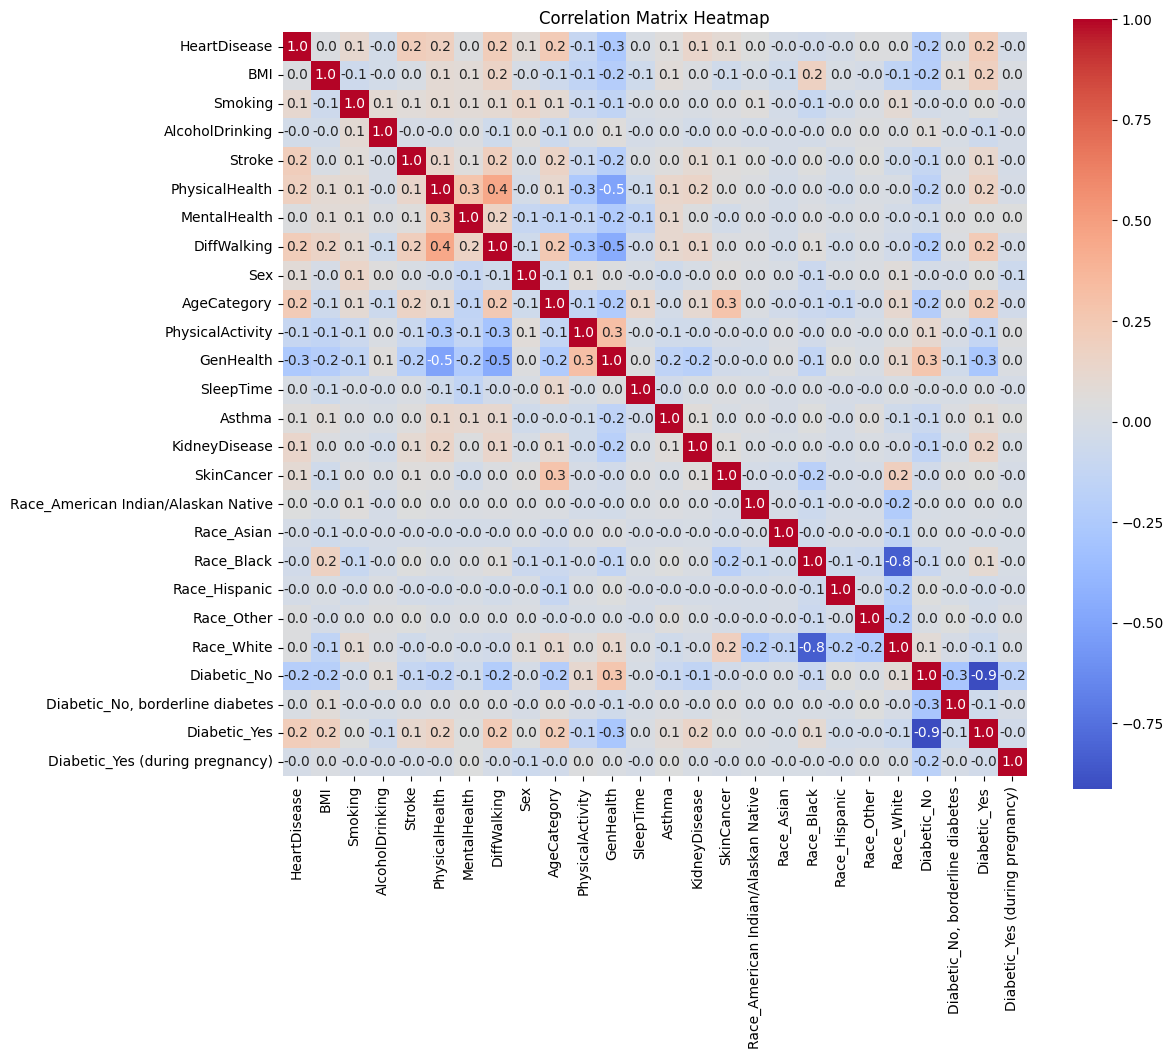

In [16]:
# Correlation Matrix and Heatmap
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

Split into Training and Testing

In [17]:
target = 'HeartDisease'
features = df.columns.drop(target)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=0, stratify=df[target])
X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

Outlier detection is primarily applied to numerical features, while categorical “outliers” are treated as rare or unusual categories.

In [18]:
# Normalization using StandardScaler
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])  
X_train 

/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_26111/851643481.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_26111/851643481.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[num_cols] = scaler.transform(X_test[num_cols])


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
2726,0.119319,0,0,0,-0.471028,-0.504748,0,1,6.0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3217,0.832007,0,0,0,-0.471028,0.092226,0,0,7.0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1508,-1.228723,1,0,0,-0.471028,-0.504748,0,1,1.0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1530,-1.492570,0,0,1,-0.471028,-0.504748,0,0,9.0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1906,1.661455,0,0,0,0.121312,0.092226,1,0,4.0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2192,-0.655540,0,0,0,-0.471028,-0.504748,0,0,5.0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4106,-0.644925,0,0,0,-0.471028,-0.265959,0,0,3.0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2260,-0.132396,1,0,0,-0.471028,0.092226,0,0,1.0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2700,0.011658,0,0,0,-0.471028,-0.504748,0,1,7.0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [19]:
# Outlier Detection using Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=0)
outlier_labels = iso_forest.fit_predict(X_train[num_cols])
# Return the number of outliers and inliers detected
num_outliers = (outlier_labels == -1).sum()
num_inliers = (outlier_labels == 1).sum()
print(f"Number of outliers detected: {num_outliers}")
print(f"Number of inliers detected: {num_inliers}")

Number of outliers detected: 200
Number of inliers detected: 3799


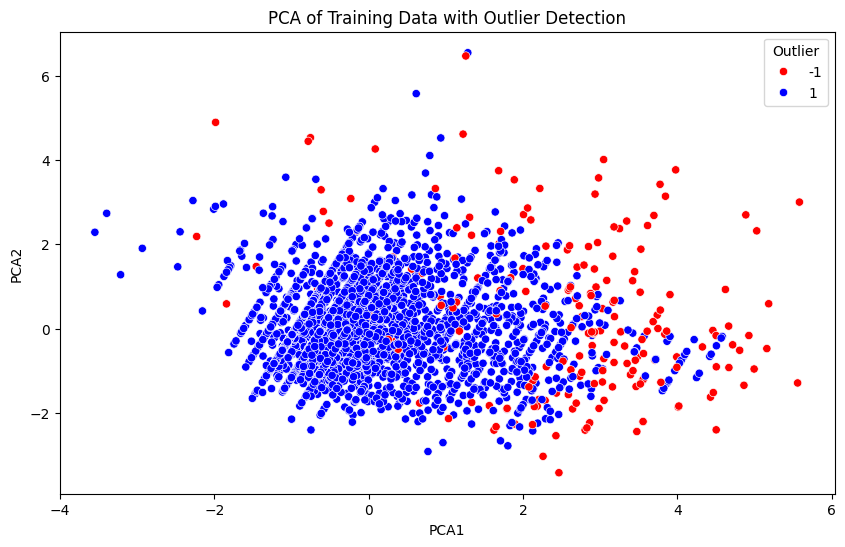

In [20]:
# Plot with PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train[num_cols])
pca_df = pd.DataFrame(data=X_train_pca, columns=['PCA1', 'PCA2'])
pca_df['Outlier'] = outlier_labels
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Outlier', data=pca_df, palette={1: 'blue', -1: 'red'})
plt.title('PCA of Training Data with Outlier Detection')
plt.show()

Normalization for numerical variables

In [21]:
# Remove outliers from training data
X_train = X_train[outlier_labels == 1]
y_train = y_train[outlier_labels == 1]

Model Training: Applied when prediction or classification is required

In [22]:
# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)
# Predict on test set
y_pred = model.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8850
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       894
           1       0.30      0.07      0.11       106

    accuracy                           0.89      1000
   macro avg       0.60      0.52      0.52      1000
weighted avg       0.84      0.89      0.85      1000



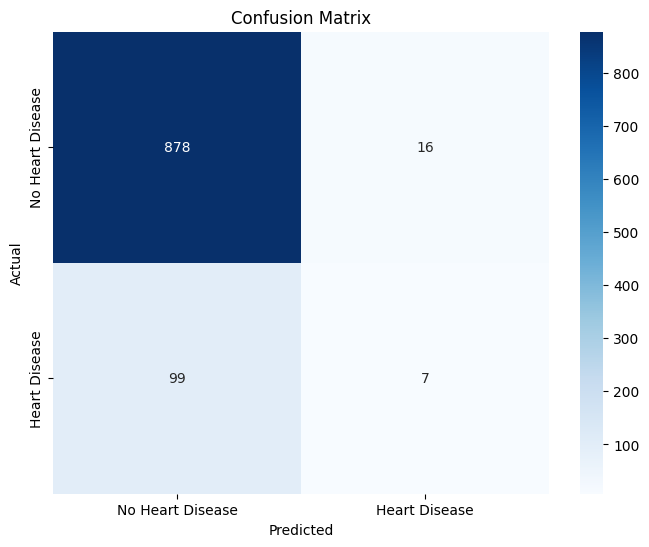

In [23]:
# Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Heart Disease', 'Heart Disease'], 
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Top 5 Important Features:
BMI
PhysicalHealth
AgeCategory
GenHealth
SleepTime


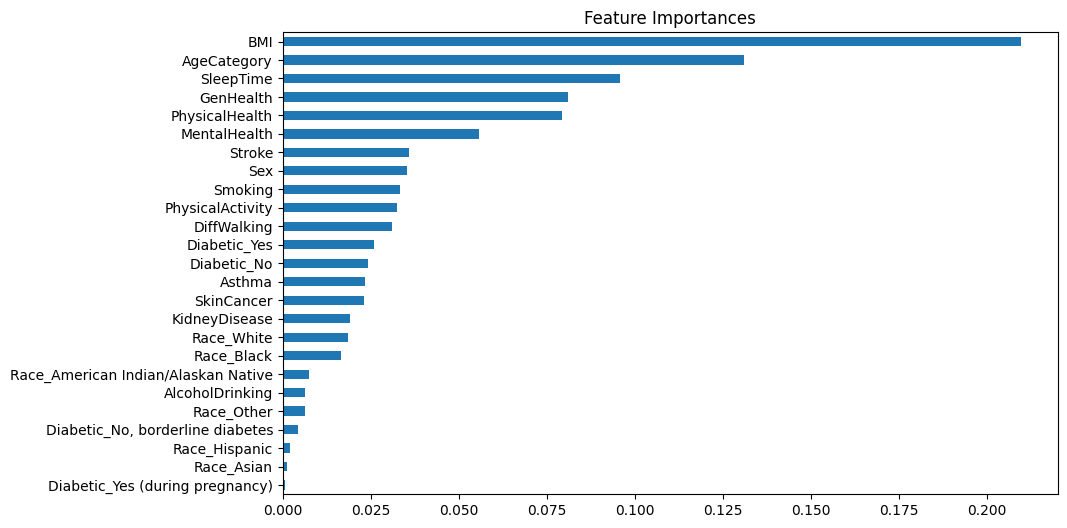

In [24]:
# Feature Importance using RFE and Random Forest
rfe = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=5)
rfe.fit(X_train, y_train)
important_features = X_train.columns[rfe.support_]
print("Top 5 Important Features:")
for feature in important_features:
    print(feature)

# Feature Importance Plot
importances = model.feature_importances_
feature_names = X_train.columns
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh')
plt.title('Feature Importances')
plt.show()

In [37]:
# Get feature importances without OHE
# Combine all OFE columns into one feature by summing their importances
# Convert to Series if needed
feat_importances = pd.Series(feat_importances, index=feature_names)

# Dictionary to accumulate importances
grouped_importance = {}

for feature, importance in feat_importances.items():
    if '_' in feature:
        base_feature = feature.split('_')[0]  # e.g. Major_AI → Major
    else:
        base_feature = feature

    grouped_importance[base_feature] = grouped_importance.get(base_feature, 0) + importance

# Convert back to Series and sort
grouped_importance = pd.Series(grouped_importance).sort_values(ascending=True)

grouped_importance

AlcoholDrinking     0.006461
KidneyDisease       0.019133
SkinCancer          0.023083
Asthma              0.023378
DiffWalking         0.031069
PhysicalActivity    0.032356
Smoking             0.033456
Sex                 0.035253
Stroke              0.035872
Race                0.051904
Diabetic            0.055206
MentalHealth        0.055867
PhysicalHealth      0.079239
GenHealth           0.081139
SleepTime           0.095776
AgeCategory         0.131135
BMI                 0.209673
dtype: float64

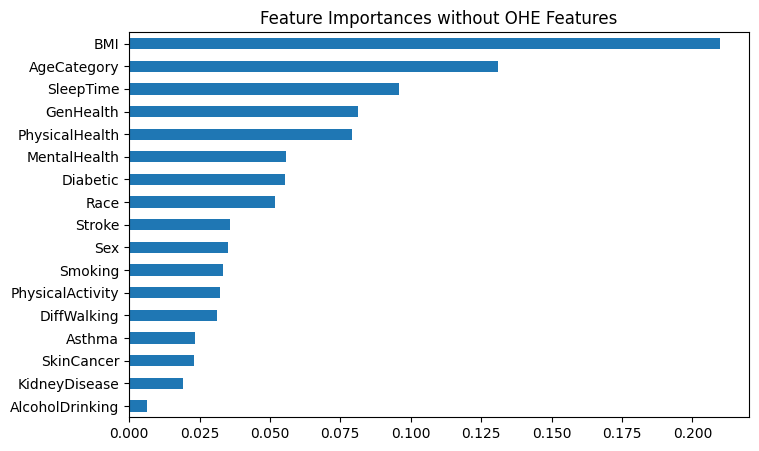

In [38]:
plt.figure(figsize=(8, 5))
grouped_importance.plot(kind='barh')
plt.title('Feature Importances without OHE Features')
plt.show()

Accuracy with Important Features: 0.87
Classification Report with Important Features:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       894
           1       0.20      0.08      0.11       106

    accuracy                           0.87      1000
   macro avg       0.55      0.52      0.52      1000
weighted avg       0.82      0.87      0.84      1000



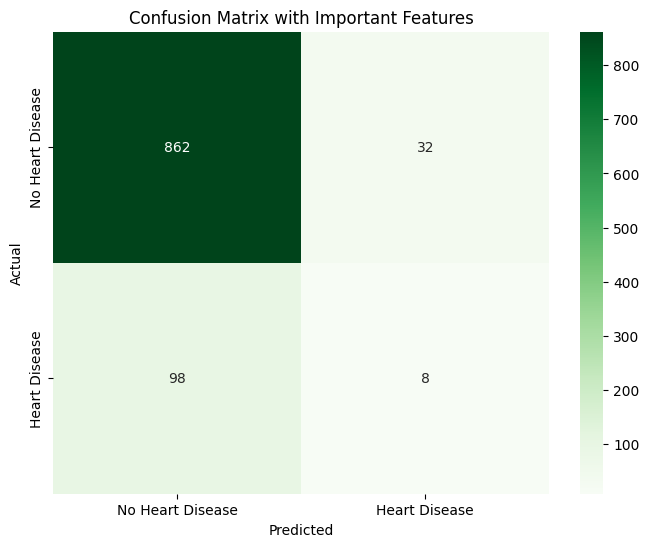

In [39]:
# Train a Random Forest Classifier with only important features
X_train_imp = X_train[important_features]
X_test_imp = X_test[important_features]
model_imp = RandomForestClassifier(n_estimators=100, random_state=42)
model_imp.fit(X_train_imp, y_train)
y_pred_imp = model_imp.predict(X_test_imp)
# Evaluate the model
accuracy_imp = accuracy_score(y_test, y_pred_imp)
print(f"Accuracy with Important Features: {accuracy_imp:.2f}")
print("Classification Report with Important Features:")
print(classification_report(y_test, y_pred_imp))
# Confusion Matrix
conf_matrix_imp = confusion_matrix(y_test, y_pred_imp)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_imp, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Heart Disease', 'Heart Disease'], 
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix with Important Features')
plt.show()

Feature selection can improve efficiency and interpretability, but model performance must always be validated empirically.

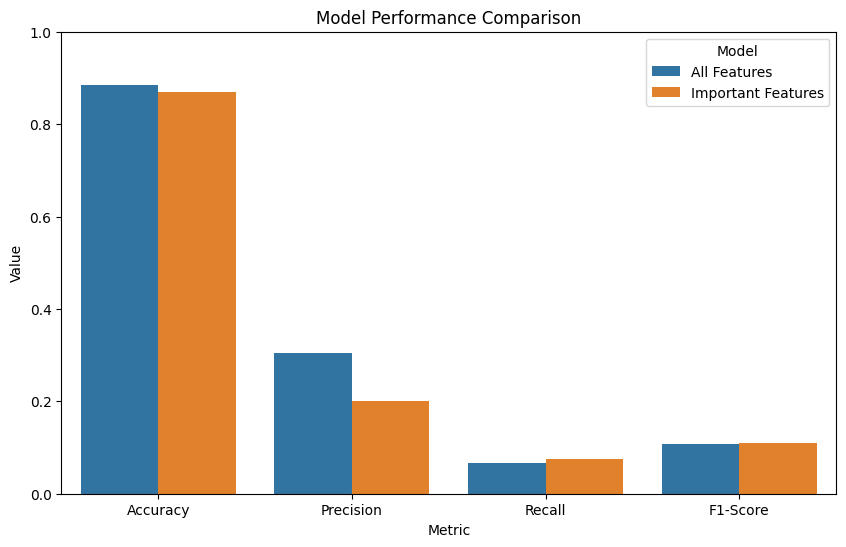

In [40]:
# A bar plot comparing metrics of both models
# Accuracy, Precision, Recall, F1-Score
from sklearn.metrics import precision_score, recall_score, f1_score
metrics = {
    'Model': ['All Features', 'Important Features'],
    'Accuracy': [accuracy, accuracy_imp],
    'Precision': [precision_score(y_test, y_pred), precision_score(y_test, y_pred_imp)],
    'Recall': [recall_score(y_test, y_pred), recall_score(y_test, y_pred_imp)],
    'F1-Score': [f1_score(y_test, y_pred), f1_score(y_test, y_pred_imp)]
}   
metrics_df = pd.DataFrame(metrics)
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Value') 
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_df_melted)
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.show()

ROC Curve Comparison

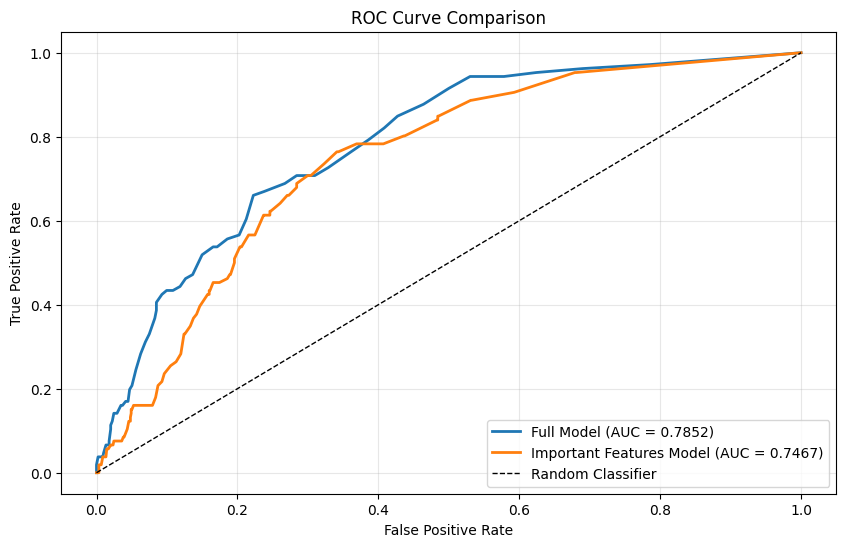

Full Model AUC: 0.7852
Important Features Model AUC: 0.7467


In [41]:
from sklearn.metrics import roc_curve, auc

# Get probability predictions for ROC curve
y_pred_proba_full = model.predict_proba(X_test)[:, 1]
y_pred_proba_imp = model_imp.predict_proba(X_test_imp)[:, 1]

# Calculate ROC curves and AUC scores
fpr_full, tpr_full, _ = roc_curve(y_test, y_pred_proba_full)
fpr_imp, tpr_imp, _ = roc_curve(y_test, y_pred_proba_imp)
auc_full = auc(fpr_full, tpr_full)
auc_imp = auc(fpr_imp, tpr_imp)

# Plot ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_full, tpr_full, label=f'Full Model (AUC = {auc_full:.4f})', linewidth=2)
plt.plot(fpr_imp, tpr_imp, label=f'Important Features Model (AUC = {auc_imp:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"Full Model AUC: {auc_full:.4f}")
print(f"Important Features Model AUC: {auc_imp:.4f}")


=== Model Comparison ===
                               Model Accuracy    AUC  Num Features
           Full Model (All Features)   0.8850 0.7852            25
Reduced Model (5 Important Features)   0.8700 0.7467             5


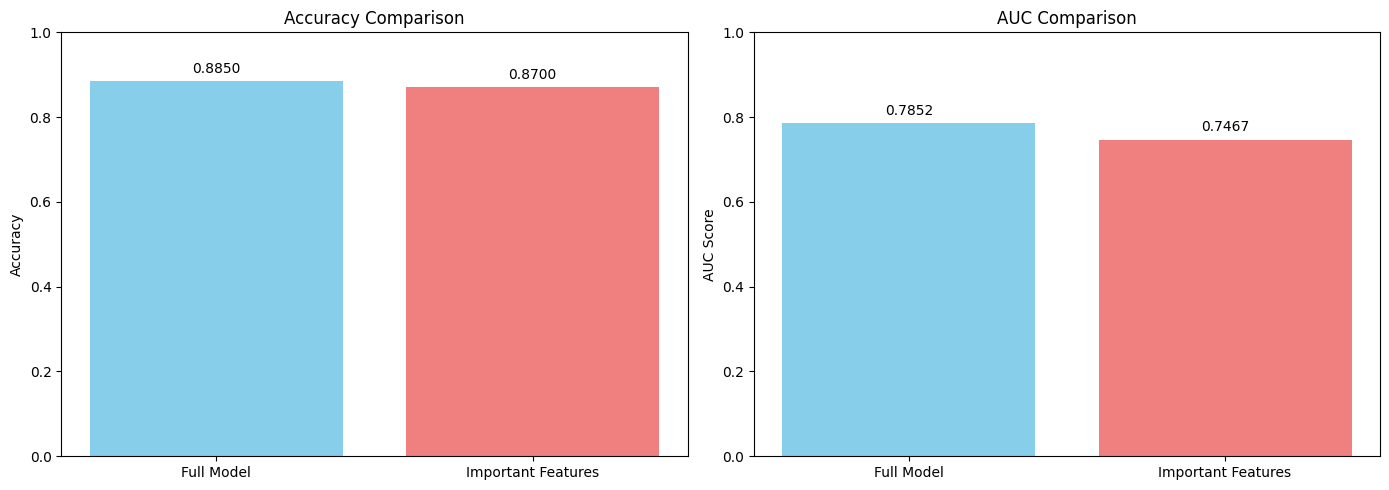


Conclusion: Feature selection achieves comparable performance with fewer features,
improving model efficiency and interpretability.


In [42]:
# Create comparison table
comparison_data = {
    'Model': ['Full Model (All Features)', 'Reduced Model (5 Important Features)'],
    'Accuracy': [f'{accuracy:.4f}', f'{accuracy_imp:.4f}'],
    'AUC': [f'{auc_full:.4f}', f'{auc_imp:.4f}'],
    'Num Features': [len(X_train.columns), len(important_features)]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Model Comparison ===")
print(comparison_df.to_string(index=False))

# Visualization comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models = ['Full Model', 'Important Features']
accuracies = [accuracy, accuracy_imp]
axes[0].bar(models, accuracies, color=['skyblue', 'lightcoral'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center')

# AUC comparison
aucs = [auc_full, auc_imp]
axes[1].bar(models, aucs, color=['skyblue', 'lightcoral'])
axes[1].set_ylabel('AUC Score')
axes[1].set_title('AUC Comparison')
axes[1].set_ylim([0, 1])
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

print("\nConclusion: Feature selection achieves comparable performance with fewer features,")
print("improving model efficiency and interpretability.")

Visualization of at least five types

In [43]:
# Group by Age and compute disease rate
age_disease_rate = df.groupby('AgeCategory')['HeartDisease'].mean()
# Convert the Age Category to the original labels
age_disease_rate.index = ordinal_encoder.categories_[0]
age_disease_rate

18-24          0.007194
25-29          0.008850
30-34          0.007092
35-39          0.023891
40-44          0.027273
45-49          0.035088
50-54          0.091765
55-59          0.098876
60-64          0.119266
65-69          0.147727
70-74          0.183794
75-79          0.225000
80 or older    0.230769
Name: HeartDisease, dtype: float64

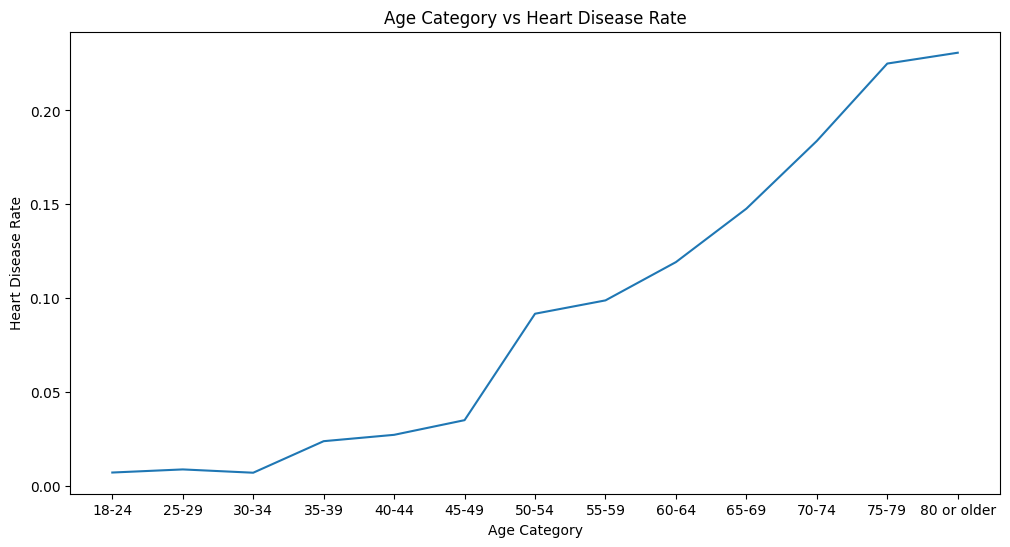

In [44]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(age_disease_rate.index, age_disease_rate.values)
plt.xlabel("Age Category")
plt.ylabel("Heart Disease Rate")
plt.title("Age Category vs Heart Disease Rate")
plt.show()

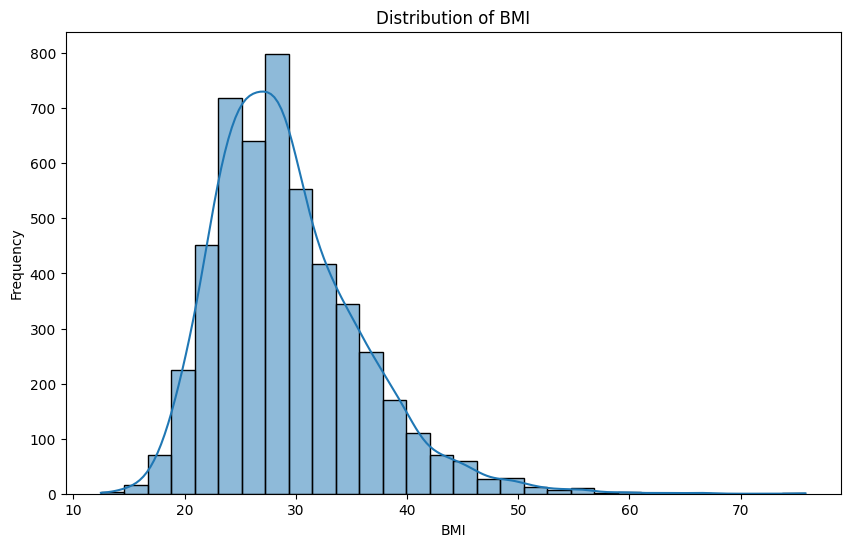

In [45]:
# Show Distribution of BMI
plt.figure(figsize=(10, 6))
sns.histplot(df['BMI'], bins=30, kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

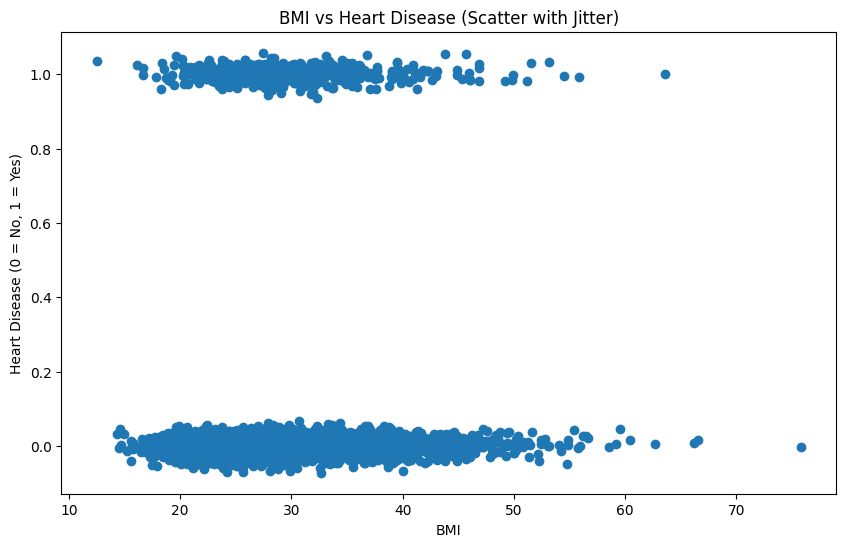

In [46]:
# A Strip Plot of BMI vs Heart Disease with Jitter
import numpy as np
# Add jitter to HeartDisease
jitter = np.random.normal(0, 0.02, size=len(df))

plt.figure(figsize=(10, 6))
plt.scatter(df['BMI'], df['HeartDisease'] + jitter)
plt.xlabel("BMI")
plt.ylabel("Heart Disease (0 = No, 1 = Yes)")
plt.title("BMI vs Heart Disease (Scatter with Jitter)")
plt.show()

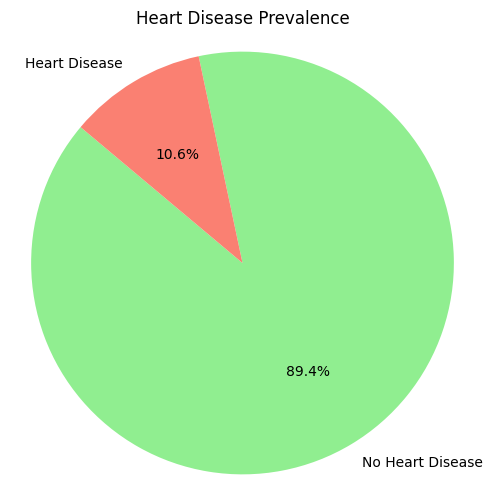

In [47]:
# Draw a pie chart of Heart Disease prevalence
heart_disease_counts = df['HeartDisease'].value_counts()
labels = ['No Heart Disease', 'Heart Disease']
sizes = heart_disease_counts.values
colors = ['lightgreen', 'salmon']
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Heart Disease Prevalence')
plt.axis('equal')
plt.show()

/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_26111/3747841891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y='BMI', data=df, palette=['lightblue', 'lightcoral'])


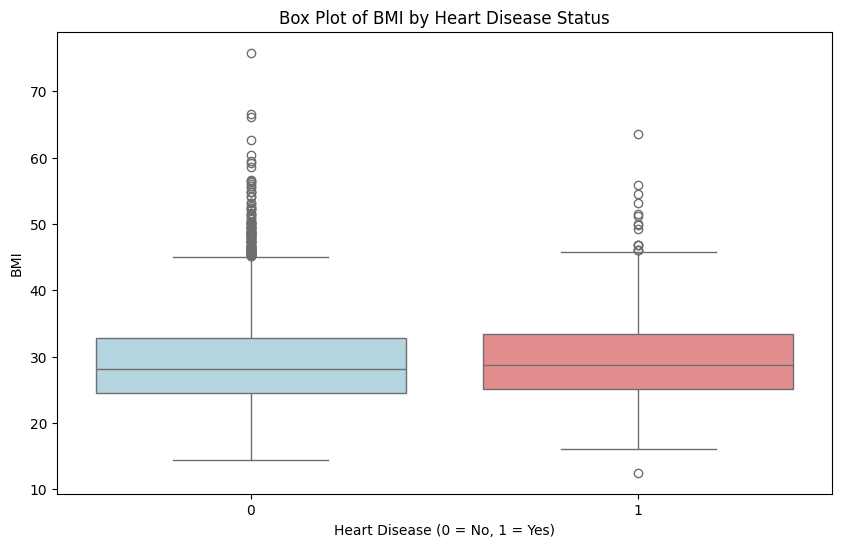

In [48]:
# Box Plot of BMI by Heart Disease Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='HeartDisease', y='BMI', data=df, palette=['lightblue', 'lightcoral'])
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("BMI")
plt.title("Box Plot of BMI by Heart Disease Status")
plt.show()